# Boston City: Merge and Clean Data for Massachusetts Crash Map
# Beta version needs further testing and review with experts
### Data from: MassDOT, BostonVisionZero Crash, Boston VisionZero Fatality
### (Expected Runtime: 3-5 minutes)

Output: 3 files in /data folder:
* boston-city-all-merged.csv - contains ALL MERGED crash records from different sources, including duplicates
* boston-city-duplicates-removed.csv - contains DUPLICATES REMOVED and displayed as side-by-side pairs of matched crash records for easy comparison
* boston-city.csv - contains CLEANED data, after duplicates removed, with one instance for each crash, prioritizing MassDOT data because it is more comprehensive

# Importing all libraries

In [1]:
# !pip install googlemaps
# uncomment the line above if we decide to pay for GOOGLE CLOUD, an estimate of the cost is below $200
# GOOGLE CLOUD can be used to geocode 16911 crashes that have addresses but not lon and lat
# more information on how to do this can be found here: https://tinyurl.com/mr42hkxw
!pip install pandas
!pip install numpy
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Collecting MassDOT crashes for Boston city ONLY (since 2021, update in 2027)

In [2]:
all_features = []

#Inserted years individually because "2023v" naming issue in MassDOT crash server
#https://gis.crashdata.dot.mass.gov/arcgis/rest/services/MassDOT

years = ['2021', '2022','2023v','2024','2025','2026']

for year in years:
   
    base_url = f"https://gis.crashdata.dot.mass.gov/arcgis/rest/services/MassDOT/MASSDOT_ODP_OPEN_{year}/FeatureServer/0/query"
    
    params = {
        "where": " CITY_TOWN_NAME = 'BOSTON' ",
        "outFields": "*",
        "outSR": "4326",
        "f": "json",
        "returnGeometry": "true",
        "resultOffset": 0,
        "resultRecordCount": 2000
    }

    while True:
        
        response = requests.get(base_url, params=params)
        data = response.json()
        features = data.get("features", [])
        
        if not features:
            break
        
        all_features.extend(features)
        params["resultOffset"] += params["resultRecordCount"]

records = [f["attributes"] for f in all_features]

df = pd.DataFrame(records)
print("Shape:", df.shape)
df.head()

Shape: (27503, 124)


,CRASH_NUMB,CITY_TOWN_NAME,CRASH_DATE_TEXT,CRASH_TIME_2,CRASH_DATETIME,CRASH_HOUR,CRASH_STATUS,CRASH_SEVERITY_DESCR,MAX_INJR_SVRTY_CL,NUMB_VEHC,...,T_EXC_TIME,F_F_CLASS,OBJECTID,TRAFFIC_CONTROL_TYPE_DESCR,NON_MTRST_ORIGIN_DEST_CL,NON_MTRST_CNTRB_CIRC_CL,NON_MTRST_DISTRACTED_BY_CL,NON_MTRST_ALC_SUSPD_TYPE_CL,NON_MTRST_DRUG_SUSPD_TYPE_CL,NON_MTRST_EVENT_SEQ_CL
0,4915103,BOSTON,01 02 2021,7:38 PM,1.609634e+12,07:00PM to 07:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),1,...,NaN,Interstate,4616461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4915101,BOSTON,01 02 2021,9:13 AM,1.609597e+12,09:00AM to 09:59AM,Closed,Non-fatal injury,Suspected Minor Injury (B),1,...,NaN,Interstate,4616463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4915422,BOSTON,01 04 2021,3:05 PM,1.609791e+12,03:00PM to 03:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,...,NaN,Interstate,4617214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4915421,BOSTON,01 03 2021,9:22 PM,1.609727e+12,09:00PM to 09:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,...,NaN,Principal Arterial - Other,4617215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4916193,BOSTON,01 01 2021,2:40 PM,1.609530e+12,02:00PM to 02:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,...,NaN,Local,4617630,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#CRASH_TIME_2 & CRASH_DATE_TEXT columns are of type str
#LAT & LON are of type float64
#The following code ensures time and date are of type datetime and lat and lon are numeric
df["CRASH_TIME"] = pd.to_datetime(df["CRASH_TIME_2"], format="%I:%M %p", errors="coerce").dt.time
df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE_TEXT"], errors="coerce")
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df = df.drop(columns=["CRASH_DATE_TEXT", "CRASH_TIME_2"])
mass_crashes = df
print("Shape of MASSDOT dataset:", mass_crashes.shape)
mass_crashes.head()

Shape of MASSDOT dataset: (27503, 124)


,CRASH_NUMB,CITY_TOWN_NAME,CRASH_DATETIME,CRASH_HOUR,CRASH_STATUS,CRASH_SEVERITY_DESCR,MAX_INJR_SVRTY_CL,NUMB_VEHC,NUMB_NONFATAL_INJR,NUMB_FATAL_INJR,...,OBJECTID,TRAFFIC_CONTROL_TYPE_DESCR,NON_MTRST_ORIGIN_DEST_CL,NON_MTRST_CNTRB_CIRC_CL,NON_MTRST_DISTRACTED_BY_CL,NON_MTRST_ALC_SUSPD_TYPE_CL,NON_MTRST_DRUG_SUSPD_TYPE_CL,NON_MTRST_EVENT_SEQ_CL,CRASH_TIME,CRASH_DATE
0,4915103,BOSTON,1.609634e+12,07:00PM to 07:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),1,0,0,...,4616461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19:38:00,2021-01-02
1,4915101,BOSTON,1.609597e+12,09:00AM to 09:59AM,Closed,Non-fatal injury,Suspected Minor Injury (B),1,1,0,...,4616463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,09:13:00,2021-01-02
2,4915422,BOSTON,1.609791e+12,03:00PM to 03:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,...,4617214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15:05:00,2021-01-04
3,4915421,BOSTON,1.609727e+12,09:00PM to 09:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,...,4617215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21:22:00,2021-01-03
4,4916193,BOSTON,1.609530e+12,02:00PM to 02:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,...,4617630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14:40:00,2021-01-01


# City of Boston Vision Zero CRASH records, then limit to 2021 onward

In [4]:
package_url = "https://data.boston.gov/api/3/action/package_show"
dataset_id = "vision-zero-crash-records"

package = requests.get(package_url, params={"id": dataset_id}).json()["result"]

resource_id = None

for r in package["resources"]:
    
    if r.get("datastore_active"):
        resource_id = r["id"]
        break

if not resource_id:
    raise Exception("No datastore-enabled resource found.")

datastore_url = "https://data.boston.gov/api/3/action/datastore_search"

limit = 5000
offset = 0
all_records = []

while True:
    
    params = {
        "resource_id": resource_id,
        "limit": limit,
        "offset": offset
    }

    response = requests.get(datastore_url, params=params).json()
    records = response["result"]["records"]

    all_records.extend(records)

    if len(records) < limit:
        break

    offset += limit

df = pd.DataFrame(all_records)
print("Shape:",df.shape)
df.head()

Shape: (42678, 11)


,_id,dispatch_ts,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,lat,long
0,1,2016-09-17 23:59:31+00,mv,Intersection,NaN,TRUMAN PKWY,WAKEFIELD AVE,757374.390000000000,2913688.580000000000,42.24270031686706,-71.12622780252731
1,2,2024-03-22 03:52:28+00,mv,Street,ARBORWAY,CUSTER ST,SAINT JOSEPH ST,759264.290000000000,2936956.420000000000,42.30653761927194,-71.11921423701752
2,3,2020-11-18 17:42:26+00,bike,Street,HORAN WAY,BICKFORD ST,PLANT CT,763522.700000000000,2943790.600000000000,42.32538900636041,-71.10332495446438
3,4,2022-01-14 21:50:58+00,mv,Street,I93,NaN,NaN,777311.540000000000,2954652.680000000000,42.35483458427184,-71.05179377553934
4,5,2019-08-03 08:32:01+00,bike,Street,AMORY ST,BRAGDON ST,W WALNUT PARK,764105.950000000000,2941665.080000000000,42.31923554012871,-71.10060005121365


In [5]:
# the dispatch_ts columns is of type str and contains information about the date and time
# lat and lon are also of type str
# the following code ensures time and date are of type datetime and lon and lat are numeric
df["CRASH_DATE"] = pd.to_datetime(df["dispatch_ts"]).dt.date
df["CRASH_TIME"] = pd.to_datetime(df["dispatch_ts"]).dt.time
df['LAT'] = df['lat']
df['LON'] = df['long']
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df['CITY_TOWN_NAME'] = 'BOSTON'
df = df[pd.to_datetime(df["dispatch_ts"]).dt.year >=2021]
df = df.drop(columns=["lat", "long","dispatch_ts"])
bvz_crash = df
print("Shape of Boston Vision Zero CRASH records:",bvz_crash.shape)
bvz_crash.head()

Shape of Boston Vision Zero CRASH records: (17622, 13)


,_id,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,CRASH_DATE,CRASH_TIME,LAT,LON,CITY_TOWN_NAME
1,2,mv,Street,ARBORWAY,CUSTER ST,SAINT JOSEPH ST,759264.290000000000,2936956.420000000000,2024-03-22,03:52:28,42.306538,-71.119214,BOSTON
3,4,mv,Street,I93,NaN,NaN,777311.540000000000,2954652.680000000000,2022-01-14,21:50:58,42.354835,-71.051794,BOSTON
5,6,bike,Intersection,NaN,PERKINS ST,FRANCIS PARKMAN DR,757899.640000000000,2941608.450000000000,2021-10-20,11:29:26,42.319308,-71.123833,BOSTON
13,14,ped,Street,CENTRE ST,ROBINWOOD AVE,BEAUFORT RD,760551.020000000000,2940737.650000000000,2022-06-27,22:09:13,42.316718,-71.113583,BOSTON
15,16,ped,Intersection,NaN,BELMORE TER,BOYLSTON ST,761526.960000000000,2941451.140000000000,2025-12-17,02:24:16,42.318832,-71.110424,BOSTON


# City of Boston Vision Zero FATALITY records, then limit to 2021 onward

In [6]:
package_url = "https://data.boston.gov/api/3/action/package_show"
dataset_id = "vision-zero-fatality-records"

package = requests.get(package_url, params={"id": dataset_id}).json()["result"]

resource_id = None

for r in package["resources"]:
    
    if r.get("datastore_active"):
        resource_id = r["id"]
        break

if not resource_id:
    raise Exception("No datastore-enabled resource found.")

datastore_url = "https://data.boston.gov/api/3/action/datastore_search"

limit = 5000
offset = 0
all_records = []

while True:
    
    params = {
        "resource_id": resource_id,
        "limit": limit,
        "offset": offset
    }

    response = requests.get(datastore_url, params=params).json()
    records = response["result"]["records"]

    all_records.extend(records)

    if len(records) < limit:
        break

    offset += limit

df = pd.DataFrame(all_records)
print("Shape:",df.shape)
df.head()

Shape: (155, 11)


,_id,date_time,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,long,lat
0,1,2021-08-27 23:16:04+00,mv,Street,HUMBOLDT AVE,BROOKLEDGE ST,SEAVER ST,766700.610000000000,2938321.020000000000,-71.09175104914614,42.31035694234807
1,2,2020-09-06 20:59:05+00,mv,Intersection,NaN,W FIRST ST,E ST,778620.860000000000,2949151.140000000000,-71.04706795221954,42.33972922713294
2,3,2016-10-25 16:18:52+00,ped,Street,WASHINGTON ST,BEETHOVEN ST,SCHOOL ST,764638.340000000000,2940024.010000000000,-71.09911264638293,42.31496798346911
3,4,2024-10-04 23:16:10+00,ped,Intersection,NaN,WASHINGTON ST,BRAHMS ST,753957.700000000000,2926135.850000000000,-71.13865114944244,42.27689709027487
4,5,2024-04-01 00:36:18+00,mv,Intersection,NaN,KING ST,DORCHESTER AVE,774510.990000000000,2931681.860000000000,-71.06260056171318,42.291851640587666


In [7]:
# NOTE that FATALITY date_time DIFFERS from CRASH dispatch_ts
# the date_time columns is of type str and contains information about the date and time
# lat and lon are also of type str
# the following code ensures time and date are of type datetime and lon and lat are numeric
df["CRASH_DATE"] = pd.to_datetime(df["date_time"]).dt.date
df["CRASH_TIME"] = pd.to_datetime(df["date_time"]).dt.time
df['LAT'] = df['lat']
df['LON'] = df['long']
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df['CITY_TOWN_NAME'] = 'BOSTON'
df = df[pd.to_datetime(df["date_time"]).dt.year >=2021]
df = df.drop(columns=["lat", "long","date_time"])
bvz_fatality = df
print("Shape of Boston Vision Zero FATALITY records:",bvz_fatality.shape)
bvz_fatality.head()

Shape of Boston Vision Zero FATALITY records: (65, 13)


,_id,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,CRASH_DATE,CRASH_TIME,LAT,LON,CITY_TOWN_NAME
0,1,mv,Street,HUMBOLDT AVE,BROOKLEDGE ST,SEAVER ST,766700.610000000000,2938321.020000000000,2021-08-27,23:16:04,42.310357,-71.091751,BOSTON
3,4,ped,Intersection,NaN,WASHINGTON ST,BRAHMS ST,753957.700000000000,2926135.850000000000,2024-10-04,23:16:10,42.276897,-71.138651,BOSTON
4,5,mv,Intersection,NaN,KING ST,DORCHESTER AVE,774510.990000000000,2931681.860000000000,2024-04-01,00:36:18,42.291852,-71.062601,BOSTON
8,9,ped,Intersection,NaN,MASSACHUSETTS AVE,ALBANY ST,771496.770000000000,2946868.370000000000,2024-01-24,08:19:15,42.333566,-71.073460,BOSTON
10,11,ped,Intersection,NaN,MERIDIAN ST,SARATOGA ST,780704.540000000000,2962232.790000000000,2025-09-25,17:59:49,42.375595,-71.039100,BOSTON


# Standardizing Different Types of Vulernable Roadway Users

See README for more detailed methodology about MassDOT data

The following code creates new columns with numerical values:
* PEDESTRIAN column = 1 if a pedestrian or similar low-speed user was involved in a crash, otherwise = 0
* CYCLIST column = 1 if a cyclist or similar micromobility user was involved in a crash, otherwise = 0
* OTHER column = 1 if higher-speed user or other type listed above or unknown was involved in a crash, otherwise = 0


In [8]:
col1 = mass_crashes["NON_MTRST_TYPE_CL"]
col2 = mass_crashes["MOST_HRMFL_EVT_CL"]

mass_crashes["PEDESTRIAN"] = np.where(
    col1.str.contains("Pedestrian|Electric Personal Assistive Mobility Device|Wheelchair|Responder|Worker", case=False, na=False) |
    col2.str.contains("Pedestrian", case=False, na=False),
    1,
    0
)

#contains Bicyclist in column1 or Cyclist in column2 = 1, but if "Motorized" = false
mass_crashes["CYCLIST"] = np.where(
    (
        col1.str.contains("Bicyclist|Cyclist|Skater|Non-Motorized Scooter Rider|Micromobility|Skateboarder|Tricyclist", case=False, na=False) |
        col2.str.contains("Cyclist", case=False, na=False)
    )
    &
    ~(
        col1.str.contains("Motorized", case=False, na=False) |
        col2.str.contains("Motorized", case=False, na=False)
    ),
    1,
    0
)

#contains Motorized Bicyclist or Motorized Scooter or moped or Other types below
mass_crashes["OTHER"] = np.where(
    mass_crashes["NON_MTRST_TYPE_CL"].str.contains("Other|Motorized Bicyclist|Motorized Scooter Rider|Passenger|Farm|Unknown", case=False, na=False) |
    mass_crashes["MOST_HRMFL_EVT_CL"].str.contains("Other Vulnerable|moped", case=False, na=False),
    1,
    0
)

mass_crashes['SEVERITY'] = mass_crashes['CRASH_SEVERITY_DESCR'].map({
    'Fatal injury': 1,
    'Non-fatal injury': 2
}).fillna(0)


mass_crashes['INTERSTATE'] = np.where(
    mass_crashes['F_CLASS'].str.contains("Interstate", case=False, na=False),
    1,
    0
)

#trims "Local police" to "Local", "State police" to "State", etc
mass_crashes['POLICE'] = mass_crashes['POLC_AGNCY_TYPE_DESCR'].str.split().str[0]
mass_crashes['ID'] = mass_crashes['CRASH_NUMB']
mass_crashes['MUNI'] = mass_crashes['CITY_TOWN_NAME']
mass_crashes = mass_crashes.drop(columns=["CITY_TOWN_NAME", "CRASH_NUMB", "POLC_AGNCY_TYPE_DESCR"])
mass_crashes['SOURCE'] = 'MassDOT'
mass_crashes['YEAR'] = pd.to_datetime(mass_crashes["CRASH_DATE"]).dt.year
mass_crashes.head()

,CRASH_DATETIME,CRASH_HOUR,CRASH_STATUS,CRASH_SEVERITY_DESCR,MAX_INJR_SVRTY_CL,NUMB_VEHC,NUMB_NONFATAL_INJR,NUMB_FATAL_INJR,MANR_COLL_DESCR,VEHC_MNVR_ACTN_CL,...,CRASH_DATE,PEDESTRIAN,CYCLIST,OTHER,SEVERITY,INTERSTATE,POLICE,ID,MUNI,SOURCE
0,1.609634e+12,07:00PM to 07:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),1,0,0,Single vehicle crash,V1: Travelling straight ahead,...,2021-01-02,0,0,0,0.0,1,State,4915103,BOSTON,MassDOT
1,1.609597e+12,09:00AM to 09:59AM,Closed,Non-fatal injury,Suspected Minor Injury (B),1,1,0,Single vehicle crash,V1: Travelling straight ahead,...,2021-01-02,0,0,0,2.0,1,State,4915101,BOSTON,MassDOT
2,1.609791e+12,03:00PM to 03:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,Rear-end,V1: Changing lanes / V2: Slowing or stopped in...,...,2021-01-04,0,0,0,0.0,1,State,4915422,BOSTON,MassDOT
3,1.609727e+12,09:00PM to 09:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,Angle,V1: Travelling straight ahead / V2: Travelling...,...,2021-01-03,0,0,0,0.0,0,State,4915421,BOSTON,MassDOT
4,1.609530e+12,02:00PM to 02:59PM,Closed,Property damage only (none injured),No Apparent Injury (O),2,0,0,Head-on,V1: Turning left / V2: Travelling straight ahead,...,2021-01-01,0,0,0,0.0,0,State,4916193,BOSTON,MassDOT


**Standardizing Boston Vision Zero CRASH records**

In [9]:
# BVZ mode_type is mutually exclusive: bike OR ped OR mv, so only code bike or ped, and ignore mv, no "other"
bvz_crash['CYCLIST'] = np.where(
    bvz_crash['mode_type'] == 'bike',
    1,
    0)

bvz_crash['PEDESTRIAN'] = np.where(
    bvz_crash['mode_type'] == 'ped',
    1,
    0)

bvz_crash['POLICE'] = ''
bvz_crash['INTERSTATE'] = ''
bvz_crash['SEVERITY'] = '2' #because EMS dispatch implies suspected injury of any type
bvz_crash['ID'] = bvz_crash['_id']
bvz_crash['MUNI'] = bvz_crash['CITY_TOWN_NAME']
bvz_crash = bvz_crash.drop(columns=["_id", "CITY_TOWN_NAME"])
bvz_crash['SOURCE'] = 'BostonVZCrash' #because listed in BVZ CRASH dataset
bvz_crash['YEAR'] = pd.to_datetime(bvz_crash["CRASH_DATE"]).dt.year
bvz_crash.head()

,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,CRASH_DATE,CRASH_TIME,LAT,LON,CYCLIST,PEDESTRIAN,POLICE,INTERSTATE,SEVERITY,ID,MUNI,SOURCE,YEAR
1,mv,Street,ARBORWAY,CUSTER ST,SAINT JOSEPH ST,759264.290000000000,2936956.420000000000,2024-03-22,03:52:28,42.306538,-71.119214,0,0,,,2,2,BOSTON,BostonVZCrash,2024
3,mv,Street,I93,NaN,NaN,777311.540000000000,2954652.680000000000,2022-01-14,21:50:58,42.354835,-71.051794,0,0,,,2,4,BOSTON,BostonVZCrash,2022
5,bike,Intersection,NaN,PERKINS ST,FRANCIS PARKMAN DR,757899.640000000000,2941608.450000000000,2021-10-20,11:29:26,42.319308,-71.123833,1,0,,,2,6,BOSTON,BostonVZCrash,2021
13,ped,Street,CENTRE ST,ROBINWOOD AVE,BEAUFORT RD,760551.020000000000,2940737.650000000000,2022-06-27,22:09:13,42.316718,-71.113583,0,1,,,2,14,BOSTON,BostonVZCrash,2022
15,ped,Intersection,NaN,BELMORE TER,BOYLSTON ST,761526.960000000000,2941451.140000000000,2025-12-17,02:24:16,42.318832,-71.110424,0,1,,,2,16,BOSTON,BostonVZCrash,2025


**Standardizing Boston Vision Zero FATALITY records**

In [10]:
# BVZ mode_type is mutually exclusive: bike OR ped OR mv, so only code bike or ped, and ignore mv, no "other"

bvz_fatality['CYCLIST'] = np.where(
    bvz_fatality['mode_type'] == 'bike',
    1,
    0)

bvz_fatality['PEDESTRIAN'] = np.where(
    bvz_fatality['mode_type'] == 'ped',
    1,
    0)

bvz_fatality['POLICE'] = ''
bvz_fatality['INTERSTATE'] = ''
bvz_fatality['SEVERITY'] = '1' # because listed in BVZ FATALITY dataset
bvz_fatality['ID'] = bvz_fatality['_id']
bvz_fatality['MUNI'] = bvz_fatality['CITY_TOWN_NAME']
bvz_fatality = bvz_fatality.drop(columns=["_id", "CITY_TOWN_NAME"])
bvz_fatality['SOURCE'] = 'BostonVZFatality'  #because listed in BVZ FATALITY dataset
bvz_fatality['YEAR'] = pd.to_datetime(bvz_fatality["CRASH_DATE"]).dt.year
bvz_fatality.head()

,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord,CRASH_DATE,CRASH_TIME,LAT,LON,CYCLIST,PEDESTRIAN,POLICE,INTERSTATE,SEVERITY,ID,MUNI,SOURCE,YEAR
0,mv,Street,HUMBOLDT AVE,BROOKLEDGE ST,SEAVER ST,766700.610000000000,2938321.020000000000,2021-08-27,23:16:04,42.310357,-71.091751,0,0,,,1,1,BOSTON,BostonVZFatality,2021
3,ped,Intersection,NaN,WASHINGTON ST,BRAHMS ST,753957.700000000000,2926135.850000000000,2024-10-04,23:16:10,42.276897,-71.138651,0,1,,,1,4,BOSTON,BostonVZFatality,2024
4,mv,Intersection,NaN,KING ST,DORCHESTER AVE,774510.990000000000,2931681.860000000000,2024-04-01,00:36:18,42.291852,-71.062601,0,0,,,1,5,BOSTON,BostonVZFatality,2024
8,ped,Intersection,NaN,MASSACHUSETTS AVE,ALBANY ST,771496.770000000000,2946868.370000000000,2024-01-24,08:19:15,42.333566,-71.073460,0,1,,,1,9,BOSTON,BostonVZFatality,2024
10,ped,Intersection,NaN,MERIDIAN ST,SARATOGA ST,780704.540000000000,2962232.790000000000,2025-09-25,17:59:49,42.375595,-71.039100,0,1,,,1,11,BOSTON,BostonVZFatality,2025


# Merging all Crash data

In [11]:
# combined massdot, bvz crash, bvz fatality
combined = pd.concat([
    mass_crashes,
    bvz_crash,
    bvz_fatality
], ignore_index=True)

In [12]:
cols_to_move = [
    "SOURCE",
    
    "ID",

    "MUNI",

    "YEAR",

    "CRASH_DATE",

    "SEVERITY",

    "CRASH_TIME",

    "POLICE",

    "CYCLIST",

    "PEDESTRIAN",

    "OTHER",

    "LAT",

    "LON",

    "INTERSTATE"
    
]
df = combined[cols_to_move + [c for c in combined.columns if c not in cols_to_move]]
df.head()

,SOURCE,ID,MUNI,YEAR,CRASH_DATE,SEVERITY,CRASH_TIME,POLICE,CYCLIST,PEDESTRIAN,...,NON_MTRST_ALC_SUSPD_TYPE_CL,NON_MTRST_DRUG_SUSPD_TYPE_CL,NON_MTRST_EVENT_SEQ_CL,mode_type,location_type,street,xstreet1,xstreet2,x_cord,y_cord
0,MassDOT,4915103,BOSTON,2021,2021-01-02 00:00:00,0.0,19:38:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MassDOT,4915101,BOSTON,2021,2021-01-02 00:00:00,2.0,09:13:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MassDOT,4915422,BOSTON,2021,2021-01-04 00:00:00,0.0,15:05:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MassDOT,4915421,BOSTON,2021,2021-01-03 00:00:00,0.0,21:22:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MassDOT,4916193,BOSTON,2021,2021-01-01 00:00:00,0.0,14:40:00,State,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# UPDATE INDEX AS NEEDED: We keep only relevant columns and drop rows that don't have a date
df_short = df.iloc[:, :14]
df_short = df_short.dropna(subset=["CRASH_DATE"])

In [14]:
# We make sure numerical data is of type int or float, and strings of type str
df_short["CRASH_DATE"] = pd.to_datetime(df_short["CRASH_DATE"]).dt.date
df_short['SEVERITY'] = pd.to_numeric(df_short['SEVERITY'], errors='coerce').astype('Int64')
df_short['INTERSTATE'] = df_short['INTERSTATE'].astype(str)
df_short['ID'] = df_short['ID'].astype(str)

In [15]:
df_short.info()

<class 'pandas.DataFrame'>
RangeIndex: 45190 entries, 0 to 45189
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SOURCE      45190 non-null  str    
 1   ID          45190 non-null  str    
 2   MUNI        45190 non-null  str    
 3   YEAR        45190 non-null  int32  
 4   CRASH_DATE  45190 non-null  object 
 5   SEVERITY    45190 non-null  Int64  
 6   CRASH_TIME  45187 non-null  object 
 7   POLICE      45188 non-null  object 
 8   CYCLIST     45190 non-null  int64  
 9   PEDESTRIAN  45190 non-null  int64  
 10  OTHER       27503 non-null  float64
 11  LAT         42690 non-null  float64
 12  LON         42690 non-null  float64
 13  INTERSTATE  45190 non-null  str    
dtypes: Int64(1), float64(3), int32(1), int64(2), object(3), str(4)
memory usage: 4.7+ MB


# Finding Duplicates Under Different conditions

In [16]:
# We combine crash date and crash time into one proper datetime column
# This allows us to compare crashes in time correctly

df = df_short.copy()

df["datetime"] = pd.to_datetime(
    df["CRASH_DATE"].astype(str) + " " + df["CRASH_TIME"].astype(str),
    errors="coerce"
)

# Sort data by time so earlier crashes come before later ones
df = df.sort_values("datetime").reset_index(drop=True)

In [17]:
# This function calculates the approximate Euclidean distance in meters 
# between two geographic coordinates (latitude and longitude)

def distance_meters(lat1, lon1, lat2, lon2):
    return np.sqrt(
        ((lat1 - lat2) * 111_000)**2 +
        ((lon1 - lon2) * 111_000 * np.cos(np.radians(lat1)))**2
    )


In [18]:
# This gives a score between 0 and 1 that tells us:
# "How likely are these two crashes actually the same event?"
# - 1.0 = almost certainly the same crash
# - 0.0 = very unlikely to be the same crash
# It uses:
# - distance (closer = more likely)
# - time difference (closer in time = more likely)

def compute_confidence(dist, dt, eps_meters, eps_seconds):

    # Convert distance into a score (closer = higher score)
    spatial = 1 - (dist / eps_meters)

    # Convert time difference into a score (closer in time = higher score)
    time = 1 - (dt / eps_seconds)

    # Make sure scores stay between 0 and 1
    spatial = max(0, min(1, spatial))
    time = max(0, min(1, time))

    # Combine both scores 
    # space is prioritized since time is not reliable as discussed
    # TESTING 0.9 spatial vs 0.1 time due to probably BVZ time zone shift
    return 0.9 * spatial + 0.1 * time


In [19]:
# This function compares crashes and finds pairs that might be duplicates
# Instead of comparing every possible pair,
# we only compare crashes that happen within a specific time window.

def find_duplicates(df, eps_meters, eps_minutes):

    EPS_SECONDS = eps_minutes * 60  # convert minutes to seconds

    duplicate_pairs = []  # this stores matching crash pairs

    n = len(df)

    # Go through each crash one by one
    for i in range(n):
        row_i = df.iloc[i]

        # Look at all future crashes after this one
        for j in range(i + 1, n):
            row_j = df.iloc[j]

            # How far apart in time are the two crashes?
            dt = (row_j["datetime"] - row_i["datetime"]).total_seconds()

            # TODO investigate if this creates a hard condition that prevents matching 6-hours apart
            # If too far apart in time, stop checking further
            # (because data is sorted, everything after will be even farther)
            if dt > EPS_SECONDS:
                break

            # We only compare crashes from different data sources
            # (same source duplicates are ignored, but can change if this is a problem too)
            if row_i["SOURCE"] == row_j["SOURCE"]:
                continue

            # Skip rows with missing location data
            if pd.isna(row_i["LAT"]) or pd.isna(row_j["LAT"]):
                continue

            # Compute how far apart they are in space in meters
            dist = distance_meters(
                row_i["LAT"], row_i["LON"],
                row_j["LAT"], row_j["LON"]
            )

            # If they are close enough in space, we consider them a possible duplicate
            if dist <= eps_meters:

                # Compute confidence score: How certain are we this is a duplicate?
                conf = compute_confidence(dist, dt, eps_meters, EPS_SECONDS)

                # Store the pair and all useful information
                duplicate_pairs.append((i, j, dist, dt, conf))

    return duplicate_pairs

In [20]:
# We try many different threshholds to see how sensitive the results are

# time is in minutes AND TEST PAIRS of 60, 180, 300, 360 minutes due to POSSIBLE BVZ 5-hour time shift?
time_thresholds = [60, 180, 300, 360]

# distance is in meters
# to change the units, the distance_meters function needs to change
distance_thresholds = [5, 30, 50, 100]

results = []

# Try every combination of time & distance thresholds
for t in time_thresholds:
    for d in distance_thresholds:

        pairs = find_duplicates(df, d, t)

        # average confidence helps us understand match quality
        avg_conf = np.mean([p[4] for p in pairs]) if len(pairs) > 0 else 0

        results.append({
            "minutes": t,
            "meters": d,
            "num_pairs": len(pairs),
            "avg_confidence": avg_conf
        })

df_results = pd.DataFrame(results)

print("\nTHRESHOLD TEST RESULTS")
print(df_results.sort_values("num_pairs"))


THRESHOLD TEST RESULTS
    minutes  meters  num_pairs  avg_confidence
0        60       5         49        0.915250
1        60      30         61        0.849002
2        60      50         70        0.805880
3        60     100         83        0.778879
4       180       5         84        0.761490
5       180      30        132        0.724515
6       180      50        165        0.679279
7       180     100        202        0.685520
8       300       5       1342        0.465105
12      360       5       1709        0.485897
9       300      30       2667        0.567344
10      300      50       3112        0.581267
13      360      30       3420        0.593707
11      300     100       3680        0.607985
14      360      50       3974        0.609644
15      360     100       4676        0.637753


In [21]:
# These are the thresholds we decide to use after reviewing results
# TESTING 360 minutes (6 hours) based on manual comparison of MassDOT & BVZ fatalities
EPS_MINUTES = 360
EPS_METERS = 100

duplicate_pairs = find_duplicates(df, EPS_METERS, EPS_MINUTES)

In [22]:
# This creates a dataset where each row contains:
# - crash A
# - crash B
# - distance between them
# - time difference
# - confidence score

pairs = []

for i, j, dist, dt, conf in duplicate_pairs:

    row_i = df.iloc[i].add_prefix("A_")
    row_j = df.iloc[j].add_prefix("B_")

    combined = pd.concat([row_i, row_j])

    combined["distance_m"] = dist
    combined["time_diff_sec"] = dt
    combined["confidence"] = conf

    pairs.append(combined)

df_pairs = pd.DataFrame(pairs).reset_index(drop=True)

In [23]:
# Creating a clean dataset without duplicates
# We decide which rows to remove so each crash appears only once
to_drop = set()

for i, j, _, _, _ in duplicate_pairs:

    # Prefer keeping MassDOT records when duplicates exist
    if df.loc[j, "SOURCE"] == "MassDOT":
        to_drop.add(i)
    elif df.loc[i, "SOURCE"] == "MassDOT":
        to_drop.add(j)
    else:
        # otherwise just drop one of them
        to_drop.add(j)

df_clean = df.drop(index=to_drop).reset_index(drop=True)


# This is the original dataset with duplicates
df_all = df_short.copy()

In [24]:
# Summary of results
print("\nFINAL SUMMARY")
print(f"Time threshold     : {EPS_MINUTES} minutes")
print(f"Distance threshold : {EPS_METERS} meters")
print(f"Number of duplicate pairs found : {len(df_pairs)}")
print(f"Average confidence score         : {df_pairs['confidence'].mean() if len(df_pairs) else 0:.3f}")

print("\nDATASET SIZES")
print(f"Original dataset : {len(df_all):,}")
print(f"Clean dataset    : {len(df_clean):,}")
print(f"Duplicate pairs  : {len(df_pairs):,}")


FINAL SUMMARY
Time threshold     : 360 minutes
Distance threshold : 100 meters
Number of duplicate pairs found : 4676
Average confidence score         : 0.638

DATASET SIZES
Original dataset : 45,190
Clean dataset    : 40,606
Duplicate pairs  : 4,676


### Renaming columns to align with Mass Crash Map¶

In [25]:
renaming = {
    "LAT": "lat",
    "LON": "lng",
    "YEAR": "year",
    "CRASH_DATE": "date",
    "CRASH_TIME": "time",
    "CYCLIST": "cyclist",
    "PEDESTRIAN": "pedestrian",
    "OTHER": "other",
    "INTERSTATE": "interstate",
    "SEVERITY": "severity",
    "ID": "id",
    "MUNI": "muni",
    "SOURCE": "source",
    "POLICE": "police"
}

df_all = df_all.rename(columns= renaming)
df_clean = df_clean.rename(columns= renaming)
df_pairs = df_pairs.rename(columns= renaming)

In [26]:
df_all.to_csv("boston-city-all-merged.csv")
df_pairs.to_csv("boston-city-duplicates-removed.csv")
df_clean.to_csv("boston-city.csv")


### REDO How many bike crashes from local source (Boston Vision Zero) are not reported in MASSDOT from 2022-2026?¶

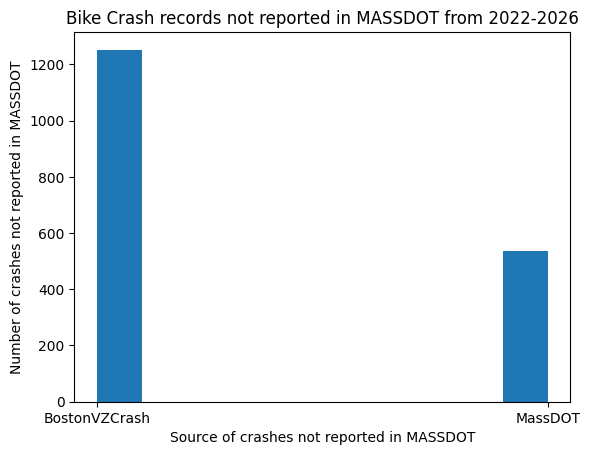

In [27]:
df_clean[(df_clean['cyclist'] == 1) & (df_clean['source'] != "MASSDOT")]['source'].hist()
plt.xlabel('Source of crashes not reported in MASSDOT')
plt.ylabel('Number of crashes not reported in MASSDOT')
plt.title('Bike Crash records not reported in MASSDOT from 2022-2026')
plt.grid(False)
plt.show()

**The following code can be used to geocode crash locations based on their address for Cambridge PD data.**

**It cannot be run at the moment as we don't have access to GOOGLE CLOUD**